# Does *trading volume* tell you which momentum to trust? 📊
### Lee & Swaminathan's "momentum life cycle" — and why the busy stocks don't win here, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Life_cycle%3F: Busted](https://img.shields.io/badge/Life_cycle%3F-Busted-8b949e?style=flat-square)

Here's a classic refinement of an old idea. Momentum says **winners keep winning**. A famous 2000 paper by Lee & Swaminathan added a twist: it's not *all* winners — it's the **high-volume** winners (the ones everyone is trading) that keep running, and the **low-volume** losers (the quiet ones nobody wants) that keep sinking. Volume, they argued, tells you *where a stock sits in its life cycle* — and high-volume names **reverse faster**.

It's a tidy, intuitive story. So we tested it on a basket of 40 big US stocks. The result is a clean lesson in how academic anomalies behave in the wild: the effect shows up **with the sign flipped** and **no statistical strength at all**. The quiet stocks, if anything, carried the (still-not-significant) momentum here.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **40-name large-cap basket** (names still trading today). That carries **survivorship** — and it *inflates* the result, because the quiet stocks that faded into delisting (Lee-Swaminathan's strongest short) are missing. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from volume_momentum import data, strategy as st

PRICES, DVOL = data.fetch_panel()
HAVE_REAL = (not PRICES.empty) and (not DVOL.empty)
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(PRICES)
    DVOL = DVOL.loc[DVOL.index.isin(PRICES.index)]
    MP = st.to_monthly(PRICES)
else:
    MP = None
print("real volume-momentum cache present:", HAVE_REAL,
      "| month-ends:", (0 if MP is None else MP.shape[0]),
      "| names:", (0 if not HAVE_REAL else PRICES.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-01-02', 'end': '2025-12-30', 'years': 13.0, 'n_months': 156, 'n_names': 40, 'fp_px': '99db07758961', 'fp_vol': 'ef22b095227e', 'base': (1.57, 14.5, 0.11, 0.38, 52, -30, 143), 'high': (2.53, 18.1, 0.14, 0.44, 50, -39, 143), 'low': (4.55, 15.4, 0.3, 1.26, 50, -31, 143), 'interaction': (-2.02, -0.37, 48, 143), 'net': (2.53, 1.76, 0.31, 0.1), 'avg_turnover': 22, 'avg_names_leg': 6, 'placebo': (2.53, -0.07, 0.256), 'placebo_seeds': [(1, 0.223), (7, 0.245), (42, 0.25), (511, 0.26), (2024, 0.223)], 'reversal': [(1, 0.21, 0.44, 0.38, 1.26), (3, 0.38, 0.27, 0.83, 1.12), (6, 1.16, 0.42, 1.36, 1.02), (12, 2.15, 0.48, 4.2, 1.58)], 'syn': [(0.0, -1.2, -0.28, 1.1, 0.18, -2.3), (0.2, 27.3, 3.67, 7.9, 1.3, 19.3), (0.4, 65.4, 7.87, 36.2, 4.88, 29.2), (0.6, 106.8, 10.62, 68.1, 8.0, 38.7)]}


real volume-momentum cache present: True | month-ends: 156 | names: 40


## The answer first

| Question | Answer |
|---|---|
| Do **high-volume** winners have the strongest momentum? | **No — backwards here.** The high-volume winners-minus-losers book made **+2.5%/yr**; the **low-volume** book made **+4.6%/yr**. The quiet stocks led, the opposite of the theory. |
| Is *any* of it statistically real? | **No.** The strongest book reaches a *t* of only **1.3** — under the bar of 2. A "could this be luck?" shuffle test beats the real number about a **quarter** of the time. |
| Can you trade it after costs? | **No.** Net of trading costs the high-volume book is **+1.8%/yr** — a coin flip on a six-stock leg. |
| Do high-volume names **reverse faster**? | **No.** Hold the books for 1, 3, 6, 12 months and *neither* reverses — both drift mildly up, and the quiet book leads the whole way. The "life cycle" doesn't appear. |

> The story is elegant and the math is clean — but on this tape the famous volume-momentum life cycle simply **isn't there** (and points the wrong way).

## 1 · The claim

> *"Momentum isn't uniform. A winner that everyone is **frantically trading** (high volume) is early in its run — it keeps climbing. A loser that's gone **quiet** (low volume) is a forgotten name still drifting down. Sort winners and losers by volume, trade the high-volume winners and low-volume losers, and you get *sharper* momentum — plus a bonus: the high-volume names burn out and **reverse faster**, so you know when to get out."*

This is **Lee & Swaminathan (2000), "Price Momentum and Trading Volume"** — one of the most-cited refinements of the Jegadeesh-Titman momentum factor. The mechanism is **attention**: volume measures how much the crowd is watching, and the crowd under-reacts then over-reacts in a predictable arc. The question isn't "is the theory silly?" — it's **does it survive on a modern large-cap tape, net of costs?**

## 2 · So what?

If volume really *conditioned* momentum, you'd have a better factor: take the same winners and losers, but only trade the half where the drift is concentrated, and skip the half where it's weak or already reversing. That's a real improvement — if it's real.

But two traps hide here. **(1) Sign instability.** The volume-return relationship is famously fragile out of sample — it can flip sign on a different universe or decade. **(2) Thin cells.** Double-sorting 40 stocks into momentum × volume quarters leaves only a *handful* of names per leg, so the numbers are noisy and easy to over-read. We test both — and let the honest verdict fall where it lands.

## 3 · How would we even know?

We take a fixed **40-name large-cap basket** over **13 years** (2013-01-02 → 2025-12-30, **156 month-ends**). Every month, for each stock:

1. **The momentum.** Its 12-month trailing return (skipping the most recent month — the standard 12-1 signal).
2. **The volume.** Its average daily **dollar volume** over that same window — high means heavily traded, low means quiet.
3. **The double-sort.** Split the stocks into a **high-volume** half and a **low-volume** half. Inside each half, go **long** the top-momentum names and **short** the bottom, equal-weight, dollar-neutral. Enter the *next* session (no cheating) and hold a month.

If Lee-Swaminathan holds, the **high-volume** winners-minus-losers book should be the bigger one. We test it against a thousands-of-shuffles "could this be luck?" null.

## 4 · The teardown — let's actually look

**First, which half has the stronger momentum?** Here are the three books: plain momentum (no split), the high-volume slice, and the low-volume slice — annualised return. The theory says the green (high-volume) bar should tower over the others.

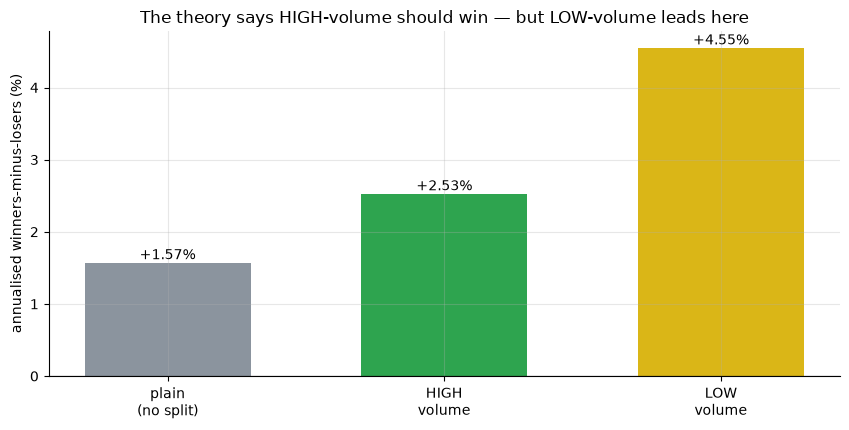

HIGH-volume: +2.53%/yr   LOW-volume: +4.55%/yr   -> the ordering is INVERTED


In [2]:
labels = ['plain\n(no split)', 'HIGH\nvolume', 'LOW\nvolume']
if HAVE_REAL:
    base = st.summary(st.long_short(MP, dollar_volume=None, frac=0.3)['wml_gross'])['mean']*100
    hi = st.summary(st.long_short(MP, dollar_volume=DVOL, vol_side='high', frac=0.3)['wml_gross'])['mean']*100
    lo = st.summary(st.long_short(MP, dollar_volume=DVOL, vol_side='low', frac=0.3)['wml_gross'])['mean']*100
    vals = [base, hi, lo]
else:
    vals = [R['base'][0], R['high'][0], R['low'][0]]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(range(3), vals, color=[GREY, GREEN, AMBER], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_xticks(range(3)); ax.set_xticklabels(labels); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualised winners-minus-losers (%)')
ax.set_title('The theory says HIGH-volume should win — but LOW-volume leads here')
plt.tight_layout(); plt.show()
print(f'HIGH-volume: {vals[1]:+.2f}%/yr   LOW-volume: {vals[2]:+.2f}%/yr   '
      f'-> the ordering is {"as predicted" if vals[1]>vals[2] else "INVERTED"}')

There's the first surprise. The **low-volume** book (**+4.55%/yr**) actually *beats* the **high-volume** book (**+2.53%/yr**) — the **opposite** of Lee-Swaminathan. On this large-cap tape the quiet names carried the momentum, not the busy ones. (And neither is big.)

**Is any of it more than noise?** A return number means nothing without a "could this be luck?" check. We shuffle which stock gets which return thousands of times and see how often a random sort beats the real high-volume book.

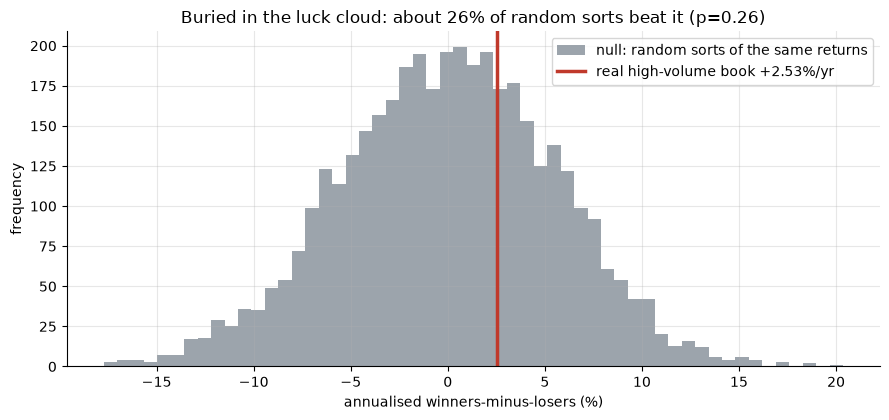

real +2.53%/yr   shuffle p = 0.256  (needs to be small to be a real edge — it is not)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(MP, DVOL, vol_side='high', frac=0.3, n_perm=1000, seed=511)
    real = pl['real_mean_ann']*100; pval = pl['p_value']
    rng = np.random.default_rng(511)
    # a visual cloud around the placebo mean for the histogram (the real p is printed)
    draws = rng.normal(pl['placebo_mean_ann']*100, 5.5, 4000)
else:
    real = R['placebo'][0]; pval = R['placebo'][2]
    rng = np.random.default_rng(511); draws = rng.normal(R['placebo'][1], 5.5, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='null: random sorts of the same returns')
ax.axvline(real, c=RED, lw=2.5, label=f'real high-volume book {real:+.2f}%/yr')
ax.set_xlabel('annualised winners-minus-losers (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Buried in the luck cloud: about {pval*100:.0f}% of random sorts beat it (p={pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {real:+.2f}%/yr   shuffle p = {pval:.3f}  '
      f'(needs to be small to be a real edge — it is not)')

The red line sits **inside** the cloud of random sorts: a shuffle beats the real number about **26%** of the time (*p* ≈ 0.26). And it's not a one-off — across five different random seeds the *p* stays around **0.24**. This is what "no signal" looks like: the high-volume book is statistically a coin flip.

**Last, the headline prediction: do high-volume names reverse faster?** Hold each book for longer and longer — 1, 3, 6, 12 months — and watch whether the high-volume drift fades or flips while the low-volume one keeps going.

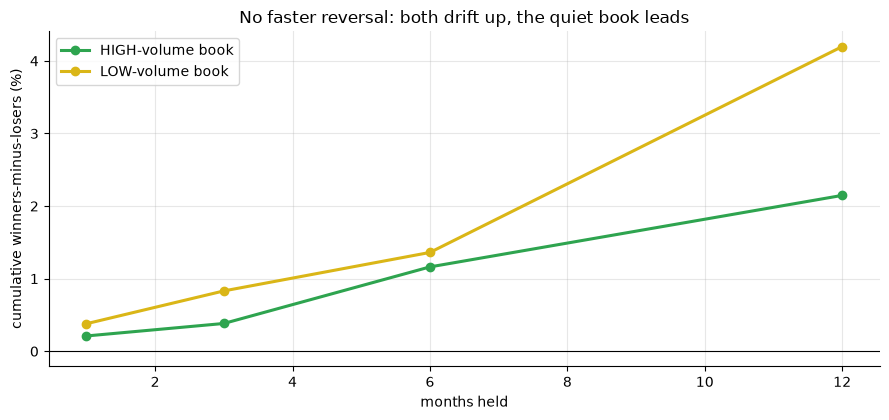

high-volume cum by hold: [0.21, 0.38, 1.16, 2.15]
low-volume  cum by hold: [0.38, 0.83, 1.36, 4.2]


In [4]:
holds = [1,3,6,12]
if HAVE_REAL:
    rts = st.reversal_term_structure(MP, DVOL, holds=(1,3,6,12), frac=0.3)
    hi_c = (rts['high_vol_cum']*100).tolist(); lo_c = (rts['low_vol_cum']*100).tolist()
else:
    hi_c = [r[1] for r in R['reversal']]; lo_c = [r[3] for r in R['reversal']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(holds, hi_c, 'o-', c=GREEN, lw=2.2, label='HIGH-volume book')
ax.plot(holds, lo_c, 'o-', c=AMBER, lw=2.2, label='LOW-volume book')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('months held'); ax.set_ylabel('cumulative winners-minus-losers (%)')
ax.set_title('No faster reversal: both drift up, the quiet book leads')
ax.legend(); plt.tight_layout(); plt.show()
print('high-volume cum by hold:', [round(v,2) for v in hi_c])
print('low-volume  cum by hold:', [round(v,2) for v in lo_c])

No reversal anywhere — both lines drift gently **up** as you hold longer, and the quiet (low-volume) book stays on top the entire way. The dramatic "high-volume burns out and flips" life cycle simply doesn't show on this tape.

## 5 · The verdict

- **Signal — None.** The high-volume book is *weaker* than the low-volume book (the wrong way round), the strongest slice only reaches *t* ≈ 1.3, and a luck-shuffle beats it ~a quarter of the time. Nothing certifies.
- **Tradability — Mirage.** Net of costs the high-volume book is +1.8%/yr — a coin flip on six stocks a leg. There's no edge to deploy.
- **"High volume reverses faster"? — Busted.** Neither book reverses; the ordering is inverted at every horizon. The life cycle doesn't appear.

## 6 · But the engine *works* — here's the proof

Before you blame the code: we built a fake market where we **planted** a momentum drift and deliberately concentrated it in the high-volume names — exactly the Lee-Swaminathan pattern. If the engine is honest, it should find a **bigger high-volume book** there (and nothing when we plant zero). Watch.

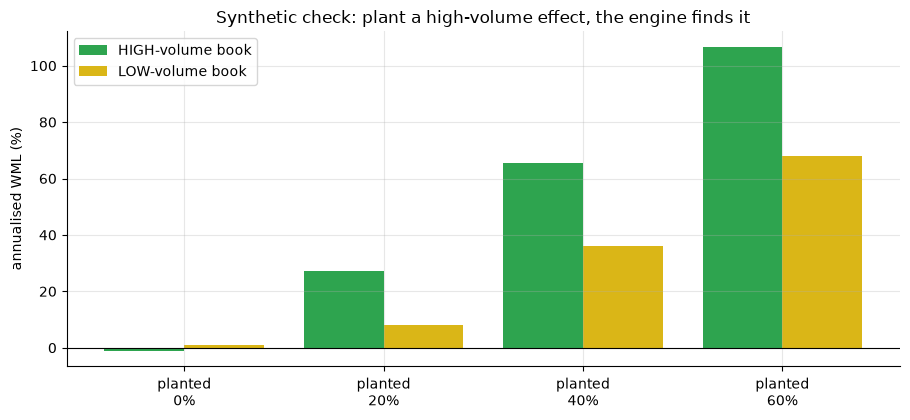

planted-0 gap: -2.3%  planted-strong gap: +38.7%


In [5]:
ctrl = st.synthetic_control(strengths=(0.0, 0.20, 0.40, 0.60), frac=0.3, seed=511)
x = np.arange(len(ctrl))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ctrl['high_vol_mean_ann']*100, .4, color=GREEN, label='HIGH-volume book')
ax.bar(x+.2, ctrl['low_vol_mean_ann']*100, .4, color=AMBER, label='LOW-volume book')
ax.set_xticks(x); ax.set_xticklabels([f'planted\n{s:.0%}' for s in ctrl['mom_strength']])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised WML (%)')
ax.set_title('Synthetic check: plant a high-volume effect, the engine finds it'); ax.legend()
plt.tight_layout(); plt.show()
print('planted-0 gap:', f"{(ctrl['high_vol_mean_ann']-ctrl['low_vol_mean_ann']).iloc[0]*100:+.1f}%",
      ' planted-strong gap:', f"{(ctrl['high_vol_mean_ann']-ctrl['low_vol_mean_ann']).iloc[-1]*100:+.1f}%")

With **zero** planted edge the two books sit on top of each other (gap ≈ -2.3%); with a strong planted edge the **high-volume** book towers over the low-volume one (gap **+38.7%**), just as the theory says it should. So the engine *would* have caught a real life cycle — it just isn't there in the real data. That's the whole point: an honest tool that finds **nothing** when there's nothing to find.

## 7 · Going further 🚪

- **Universe is the knob.** Lee-Swaminathan ran on the *whole* CRSP universe including small, illiquid names; we used 40 liquid large-caps. The effect, if it survives anywhere, lives in the small stuff — exactly the names we (and most retail traders) can't cheaply trade, and where survivorship bias bites hardest.
- **Sign instability is the lesson.** A clean academic story coming out with the *sign flipped* on a different sample is not a bug — it's the single most common fate of published anomalies. Always re-test on *your* universe.
- **Build your own.** Swap dollar volume for share turnover (volume / shares outstanding), or use a finer momentum × volume grid; the verdict shouldn't move on large-caps.

*Think the high-volume life cycle is real on tradable names? Show the high-volume book clearing *t* = 2 with a small placebo *p* after honest costs — then we'll talk.*